In [3]:
library(hdf5r)
library(Seurat)
library(ggplot2)
library(stringr)
#####feature plot
library(Seurat)
library(ggplot2)
library(cowplot)
library(dplyr)
library(tidyr)
library(stringr)
library(viridis)
library(reshape2)
library(patchwork)
library(ggplot2)
library(ggridges)
library(RColorBrewer)
library(scales)
library("circlize")
library(ComplexHeatmap)
library(ggplot2)
library(reshape2)

In [4]:
#####marophage
mer <- readRDS("/DATA/User/liqian7/pienapple/06final_ST_AS_update/03figure4/03result_plot/merge_alldata_addmodulescore.RDS")
# mer$layer_aa_da <- abs(mer$layer_aa_da-100)
mer1 <- subset(mer,subset = sample=="save")
mer2 <- subset(mer1,subset = first_type=="Macrophage")
mer3 <- subset(mer2,subset = roi==1)

In [2]:
order <- c('W20_N','W0','W2','W6','W10','W20')
week <- order
mer$week <- factor(mer$week,levels = order)
cols <- c('W0'= '#FFE3F0','W2'='#EFA5B9','W6'='#E4D7FF','W10'='#ABA0FB','W20'='#736DC2','W20_N'="#A1CFFA")

ERROR: Error in factor(mer$week, levels = order): 找不到对象'mer'


In [5]:
exp <- as.data.frame(mer3@assays$RNA@data)

Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 21.2 GiB”


In [6]:
exp <- subset(exp,subset=rownames(exp)%in%c("Mmp12","Lgals3"))

In [7]:
m <- merge(mer3@meta.data,t(exp),all = TRUE,by = 0)
rownames(m) <- m$Row.names
m <- m[,-1]

In [8]:
order <- c('W20_N','W0','W2','W6','W10','W20')
week <- order
m$week <- factor(m$week,levels = order)
cell_type_cols <- c('W0'= '#FFE3F0','W2'='#EFA5B9','W6'='#E4D7FF','W10'='#ABA0FB','W20'='#736DC2','W20_N'="#A1CFFA")

In [ ]:
p <- ggplot(m,aes(x=layer_aa_da,y = Lgals3,fill=week,color=week))+theme_classic ()+
labs(title = "Lgals3")+geom_smooth(method = "gam",span=1,se = T,level=0.90,alpha=0.15)+scale_color_manual(values = cell_type_cols)+scale_fill_manual(values = cell_type_cols)+
labs(x="Layer",y="Gene Expression")+theme(axis.text = element_text (size = 20))+#调整坐标轴字体大小
    theme(axis.title.x=element_text(vjust=0, size=25,face = "plain"))+#调整xlab字体大小
    theme(axis.title.y=element_text(vjust=0, size=25,face = "plain"))+#调整ylab字体大小
    theme(plot.title = element_text(size = 25, face = "bold"))+
    theme(axis.line = element_line(color = "black",linewidth = 0.8))+#调整坐标轴样式
    theme(legend.title = element_text(size=20),  # 调整图例标题的大小
          legend.text = element_text(size=15))+ theme(axis.text.x = element_blank(),
          axis.ticks.x = element_blank())
p

In [10]:
p2 <- p+theme(panel.border = element_rect(color = "black", fill = NA, linewidth = 2))

`geom_smooth()` using formula = 'y ~ s(x, bs = "cs")'


In [ ]:
p <- ggplot(m,aes(x=layer_aa_da,y = Mmp12,fill=week,color=week))+theme_classic ()+
labs(title = "Mmp12")+geom_smooth(method = "gam",span=1,se = T,level=0.90,alpha=0.15)+scale_color_manual(values = cell_type_cols)+scale_fill_manual(values = cell_type_cols)+
labs(x="Layer",y="Gene Expression")+theme(axis.text = element_text (size = 20))+#调整坐标轴字体大小
    theme(axis.title.x=element_text(vjust=0, size=25,face = "plain"))+#调整xlab字体大小
    theme(axis.title.y=element_text(vjust=0, size=25,face = "plain"))+#调整ylab字体大小
    theme(plot.title = element_text(size = 25, face = "bold"))+
    theme(axis.line = element_line(color = "black",linewidth = 0.8))+#调整坐标轴样式
    theme(legend.title = element_text(size=20),  # 调整图例标题的大小
          legend.text = element_text(size=15))+ theme(axis.text.x = element_blank(),
          axis.ticks.x = element_blank())
p
p2 <- p+theme(panel.border = element_rect(color = "black", fill = NA, linewidth = 2))

In [3]:
drds <- "/DATA/User/liqian7/pienapple/24AS_fig_add/00DATA/05mm_data/"
n=0
for(s in Sys.glob(file.path(drds,"*_mm.RDS"))){
    n=n+1
    key <- gsub("_mm.RDS","",basename(s))
    sp <- readRDS(paste0(drds,key,"_mm.RDS"))
    m <- sp@meta.data
    rownames(m) <- paste0(key,rownames(m))
    if(n==1){
        m1 <- m
    }
    else{
        m1 <- rbind(m1,m)
    }
}

In [4]:
colnames(m1)

[1] "Rownames"            "nCount_RNA"          "nFeature_RNA"       
 [4] "Chip"                "Chip ID"             "x"                  
 [7] "y"                   "Location"            "GC_LC"              
[10] "Aortic Area"         "Digitization Layer"  "Digitization Column"
[13] "Plaque Score"        "Celltype"            "First_ratio"        
[16] "Second_ratio"        "Ann class1"          "Ann class2"         
[19] "Ann class3"          "Macro. ann1"         "Macro. ann2"        
[22] "Week"                "Week ID"             "rown"               
[25] "ann1"                "ann2"                "ann3"               
[28] "tissue1"             "sample"              "stage"              
[31] "cd"

In [5]:
table(m1$`Macro. ann1`)
table(m1$`Macro. ann2`)


    monocytes_ms Other_macrophage           SMC_ms          TRMs_ms 
           24010            98012            62259            27186 


   adventitia_ms         Foamy_ms        intima_ms Other_macrophage 
           29268            59504            48163            74532 

In [6]:
mer1 <- subset(m1,subset = sample=="save")
table(mer1$`Macro. ann2`)
mer3 <- subset(mer1,subset = `Macro. ann2`%in%c("adventitia_ms","intima_ms"))
mer4 <- subset(mer3,subset = stage%in%c("stage1","stage2"))


   adventitia_ms         Foamy_ms        intima_ms Other_macrophage 
           26738            54494            43977            65116 

In [7]:
mer5 <- mer4

In [26]:
# mer5$`Digitization Layer` <- abs(mer5$`Digitization Layer`-100)

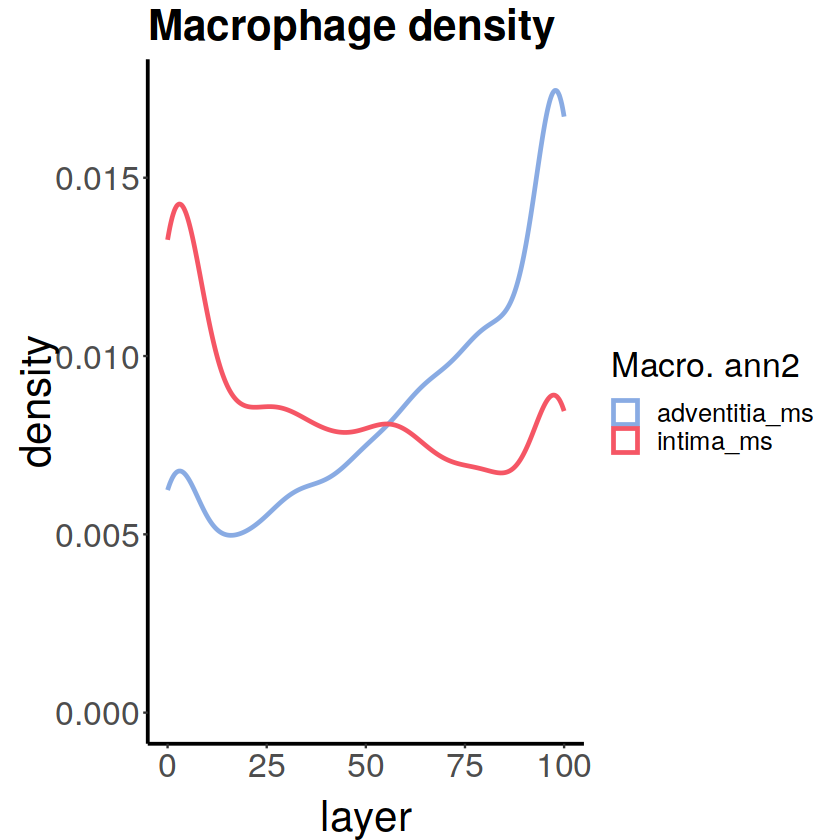

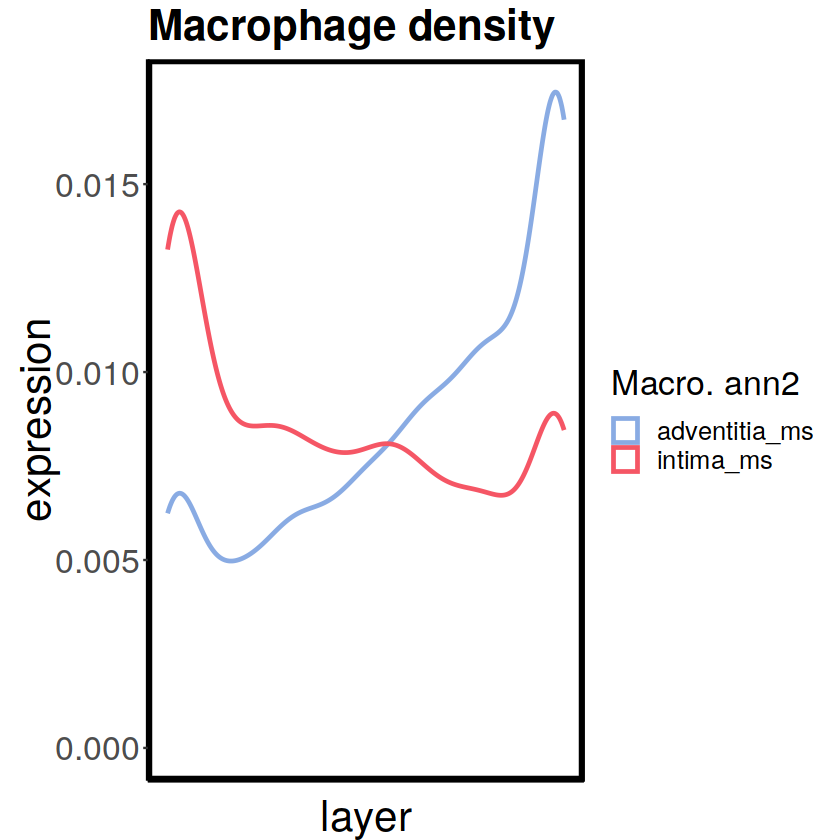

In [12]:
p1 <- ggplot(mer5, aes(x=`Digitization Layer`, color=`Macro. ann2`)) +
  geom_density(size=1)+scale_colour_manual(values = c("#89ABE3FF","#F55665FF"))+theme_classic()+labs(title="Macrophage density", x="layer", y="density")+
    theme(axis.text = element_text (size = 20))+#调整坐标轴字体大小
    theme(axis.title.x=element_text(vjust=0, size=25,face = "plain"))+#调整xlab字体大小
    theme(axis.title.y=element_text(vjust=0, size=25,face = "plain"))+#调整ylab字体大小
    theme(plot.title = element_text(size = 25, face = "bold"))+
    theme(axis.line = element_line(color = "black",linewidth = 0.8))+#调整坐标轴样式
    theme(legend.title = element_text(size=20),  # 调整图例标题的大小
          legend.text = element_text(size=15))#+ coord_cartesian(ylim = c(0.004, 0.018))
p1
p2 <- p1+labs(x="layer",y="expression")+theme(panel.border = element_rect(color = "black", fill = NA, linewidth = 2))+theme(axis.text.x = element_blank(),
          axis.ticks.x = element_blank())
ggsave("update_S3_Macro_adventima_intima_update.pdf",p1,width = 8,height = 6)
p2